# Midterm Project: Комплексный DL-проект

**Занятие 39 | Неделя 20**

## Задание

Выполните комплексный проект по Deep Learning, используя методы из курса.

**Дедлайн:**
- Презентация (5-6 минут) — на занятии 40
- Код (этот ноутбук) — до вторника следующей недели

**Критерии оценки:**

| Критерий | Вес | Описание |
|----------|-----|----------|
| Качество кода и ноутбука | 40% | Чистый код, комментарии, структура, воспроизводимость |
| Результаты и метрики | 25% | Модель обучена, метрики посчитаны, результаты адекватны |
| Презентация (5-6 мин) | 20% | Чёткое изложение, визуализация, ответы на вопросы |
| Анализ и сравнение | 15% | Сравнение подходов, анализ ошибок, выводы |

---
## Выберите трек

Раскомментируйте свой трек и опишите задачу:

| Трек | Задача | Данные | Модели |
|------|--------|--------|--------|
| Vision: Classification | Классификация изображений | CIFAR-10, Fashion-MNIST, Chest X-Ray или свой | CNN → ResNet / EfficientNet |
| Vision: Detection | Object Detection | CAFD (казахская еда) или свой | YOLOv8 fine-tune |
| NLP: Text | Sentiment / Classification | KazSAnDRA или свой текстовый датасет | BERT / mBERT fine-tune |
| Свой вариант | Своя задача | Свой датасет | Методы из курса обязательны |

---
## 0. Информация о проекте

Заполните информацию о вашем проекте.

**Имя студента:** Жексенбаева Дана

**Трек:** Vision Detection

**Задача:** Определение позиции человека, в особенности падения

**Датасет:** Falling Detection on Roboflow

**Модели для сравнения:** YOLOv8 и YOLOv11

---
## 1. Подготовка окружения

Убедитесь, что Runtime → Change runtime type → **T4 GPU**

In [5]:
# Установите необходимые библиотеки (при необходимости)
!pip install ultralytics -q

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter
import random
import cv2
import torchvision.transforms as transforms
from PIL import Image
from ultralytics import YOLO
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns


print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 3060
Device: cuda


---
## 2. Загрузка и исследование данных (EDA)

Загрузите датасет и проведите разведочный анализ:
- Размер датасета (train / val / test)
- Распределение классов
- Примеры данных (изображения / тексты)
- Есть ли дисбаланс? Как будете решать?

In [3]:
# Загрузка датасета

!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="MtyKL8KKeTmmroCkiEwC")
project = rf.workspace("danas-workspace-pat4w").project("fall-detection-acou5-1en20")
version = project.version(2)
dataset = version.download("yolov8")

print(f"Датасет успешно скачан в формате YOLOv8: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 744.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 17.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fall-Detection-2 in yolov8:: 100%|██████████| 19075/19075 [00:03<00:00, 6109.97it/s] 


✅ Датасет успешно скачан в формате YOLOv8: /content/Fall-Detection-2


Train: 6668
Validation: 1909
Test: 958
Counter({3: 4949, 2: 2647, 1: 2318, 0: 1382})


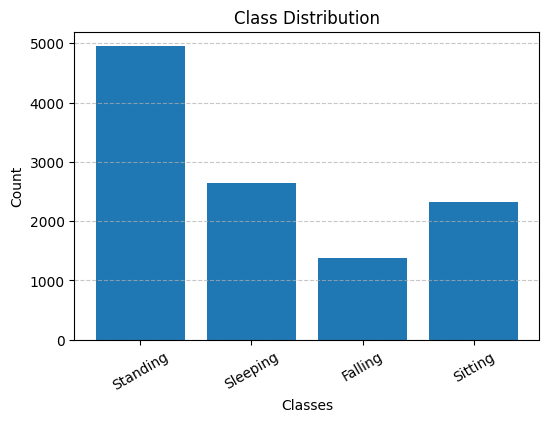

In [ ]:
def count_images(path):
    return len([f for f in os.listdir(path) if f.endswith(('.jpg', '.png', '.jpeg'))])

base_path = dataset.location

train_count = count_images(os.path.join(base_path, "train/images"))
val_count = count_images(os.path.join(base_path, "valid/images"))
test_count = count_images(os.path.join(base_path, "test/images"))

print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

class_names = ['Falling', 'Sitting', 'Sleeping', 'Standing']

def count_classes(label_path):
    counter = Counter()

    for file in os.listdir(label_path):
        if file.endswith(".txt"):
            with open(os.path.join(label_path, file)) as f:
                for line in f:
                    class_id = int(line.split()[0])
                    counter[class_id] += 1

    return counter

train_labels = os.path.join(base_path, "train/labels")
class_counts = count_classes(train_labels)

print(class_counts)

classes = list(class_counts.keys())
counts = list(class_counts.values())

labels = [class_names[i] for i in classes]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

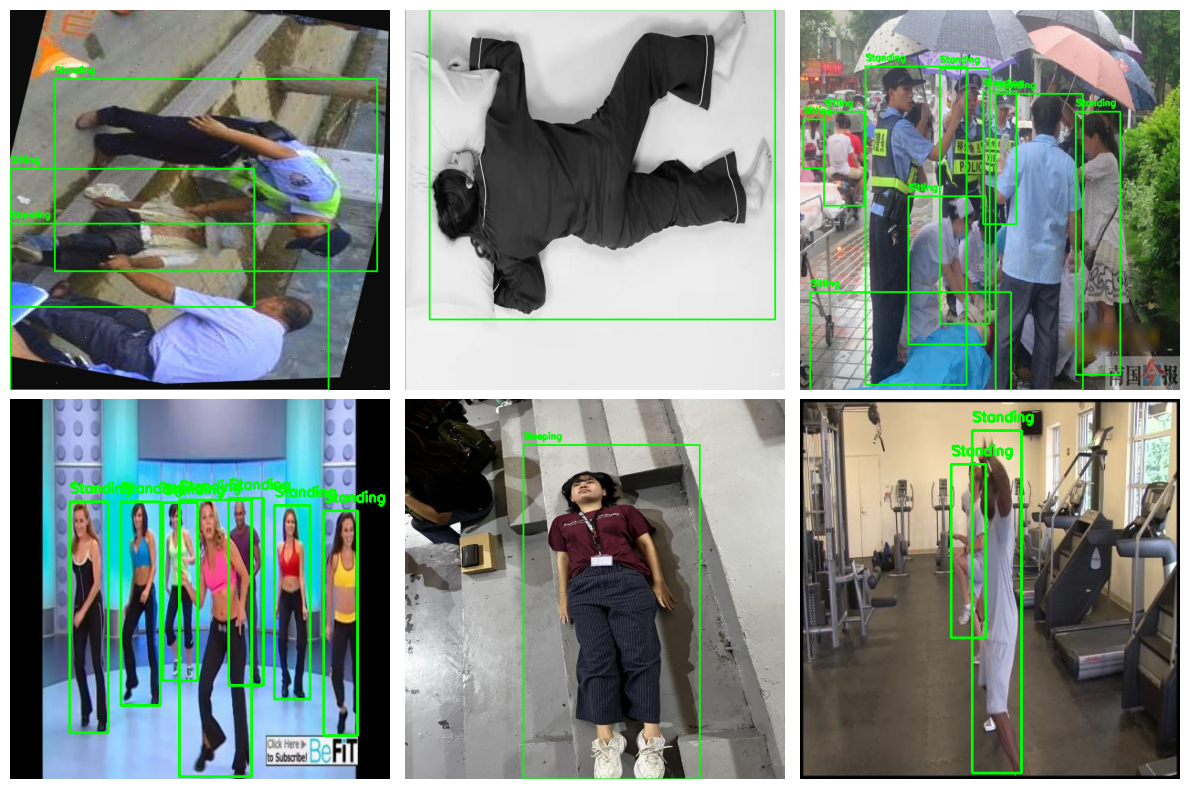

In [ ]:
# Примеры данных — покажите 5-10 образцов


image_dir = os.path.join(dataset.location, "train/images")
label_dir = os.path.join(dataset.location, "train/labels")

images = os.listdir(image_dir)
sample_images = random.sample(images, 6)

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                class_id, x, y, bw, bh = map(float, line.split())

                # перевод из YOLO в пиксели для рамок
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                # Рамка Bounding box
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

                # подпись класса
                label = class_names[int(class_id)]
                cv2.putText(img, label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


**Выводы по EDA:**

[Опишите: сколько данных, есть ли дисбаланс, качество данных, особенности]

---
## 3. Подготовка данных

Создайте DataLoader / подготовьте данные для обучения:
- Препроцессинг (resize, normalize и т.д.)
- Аугментация (для train)
- Train / Val / Test split
- Борьба с дисбалансом (если есть)

In [ ]:
# Препроцессинг и аугментация


transform_pipeline = transforms.Compose([

    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [ ]:
# Создание DataLoader / токенизация

# Токенизация для модели YOLO не нужна, и в библиотеке ultralytics создание DataLoader происходит автоматически.

---
## 4. Модель 1 (Baseline)

Первая модель — ваш baseline. Это должна быть модель из курса:
- Vision: CNN с нуля
- Detection: YOLOv8n (nano)
- NLP: BERT с дефолтными гиперпараметрами

Опишите архитектуру и обоснуйте выбор.

In [26]:
# Определение Модели 1

model = YOLO('yolov8n.pt')
model.info()


YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
# Обучение Модели 1

results = model.train(
    data='/content/Fall-Detection-2/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    workers=0,
    patience=10,
    device=0,
    augment=True,
    degrees=10.0,
    flipud=0.0,
    fliplr=0.5,
    hsv_v=0.4,
    mosaic=1.0,
    name='Aura_Baseline_YOLOv8n',
    seed=42
)

print("Обучение YOLOv8 завершено!")
print(f"Лучшие веса сохранены в: {results.save_dir}/weights/best.pt")


---
## 5. Модель 2 (Улучшенная)

Вторая модель — улучшение. Используйте метод из курса:
- Vision: ResNet18 / EfficientNet (Transfer Learning)
- Detection: YOLOv8s/m (bigger model) или другие гиперпараметры
- NLP: другой lr, max_length, или другая BERT-модель

Опишите, что изменили и почему.

In [27]:
# Определение Модели 2

model_v11 = YOLO('yolo11n.pt')
model_v11.info()



YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [ ]:
# Обучение Модели 2
results_v11 = model_v11.train(
    data='/content/Fall-Detection-2/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,          # Уменьшаем до 16 для стабильности
    workers=0,         # Уменьшаем количество потоков (это решит ошибку SHM)
    patience=10,
    device=0,
    augment=True,
    degrees=10.0,       # Замена RandomRotation
    flipud=0.0,         # Отключаем переворот «вверх ногами» (люди не падают с потолка)
    fliplr=0.5,         # Замена RandomHorizontalFlip (50% шанс)
    hsv_v=0.4,          # Замена ColorJitter (яркость)
    mosaic=1.0,
    name='Aura_Baseline_YOLOv8n',
    seed=42
)

print("Обучение YOLOv11 завершено!")
print(f"Лучшие веса сохранены в: {results_v11.save_dir}/weights/best.pt")


---
## 6. Модель 3 (Опционально — бонус)

Третья модель — дополнительное сравнение:
- Другая архитектура из курса
- Или своя модель (не из курса) для сравнения

Этот раздел не обязателен, но добавит баллы за анализ.

---
## 7. Сравнение моделей

Сравните все модели на **тестовом** наборе данных.

Обязательно:
- Таблица с метриками (Accuracy, F1, Precision, Recall)
- Learning curves (loss и accuracy по эпохам)
- Confusion matrix для каждой модели

📊 Оцениваем YOLOv8...
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1187.0±614.4 MB/s, size: 30.6 KB)
val: Scanning /content/Fall-Detection-2/valid/labels.cache... 1909 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1909/1909 800.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 6.9it/s 17.3s
                   all       1909       3174      0.798      0.752      0.818      0.566
               Falling        384        391      0.728       0.78      0.806      0.516
               Sitting        404        700      0.735      0.562      0.696      0.456
              Sleeping        697        770      0.976      0.966      0.983      0.754
              Standing        541       1313      0.754      0.702      0.785      0.

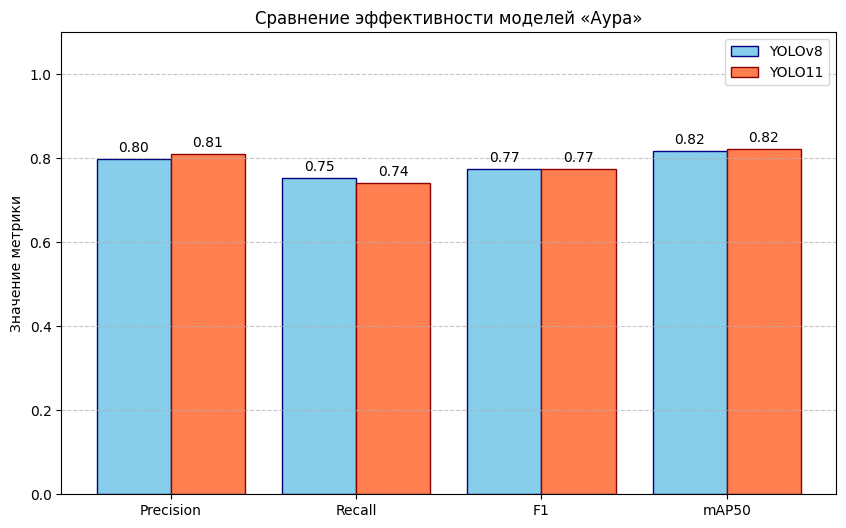

✅ График успешно построен!


In [14]:
# Таблица сравнения метрик

# Загрузка моделей по путям, т.к. веса приходится импортировать из-за того, что runtime дисконнектится
model_v8 = YOLO('/content/runs/detect/Aura_Baseline_YOLOv8n4/weights/best.pt')
model_v11 = YOLO('/content/runs/detect/Aura_Baseline_YOLOv8n5/weights/best.pt')

dataset_path = dataset.location + '/data.yaml'

# Запуск валидации
res_v8 = model_v8.val(data=dataset_path, workers=0)
res_v11 = model_v11.val(data=dataset_path, workers=0)

# Извлечение метрик
def extract_vals(metrics_obj):
    p = metrics_obj.box.mp%%!
    r = metrics_obj.box.mr
    m50 = metrics_obj.box.map50
    f1 = 2 * (p * r) / (p + r + 1e-6)
    return [p, r, f1, m50]

v8_vals = extract_vals(res_v8)
v11_vals = extract_vals(res_v11)

# Построение итогового графика
labels = ['Precision', 'Recall', 'F1', 'mAP50']
x = np.arange(len(labels))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, v8_vals, width=0.4, label='YOLOv8', color='skyblue', edgecolor='navy')
plt.bar(x + 0.2, v11_vals, width=0.4, label='YOLO11', color='coral', edgecolor='darkred')

for i in range(len(x)):
    plt.text(x[i] - 0.2, v8_vals[i] + 0.01, f'{v8_vals[i]:.2f}', ha='center', va='bottom')
    plt.text(x[i] + 0.2, v11_vals[i] + 0.01, f'{v11_vals[i]:.2f}', ha='center', va='bottom')

plt.xticks(x, labels)
plt.ylim(0, 1.1)
plt.ylabel('Значение метрики')
plt.title('Сравнение эффективности моделей «Аура»')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("График успешно построен!")


✅ Логи успешно загружены!


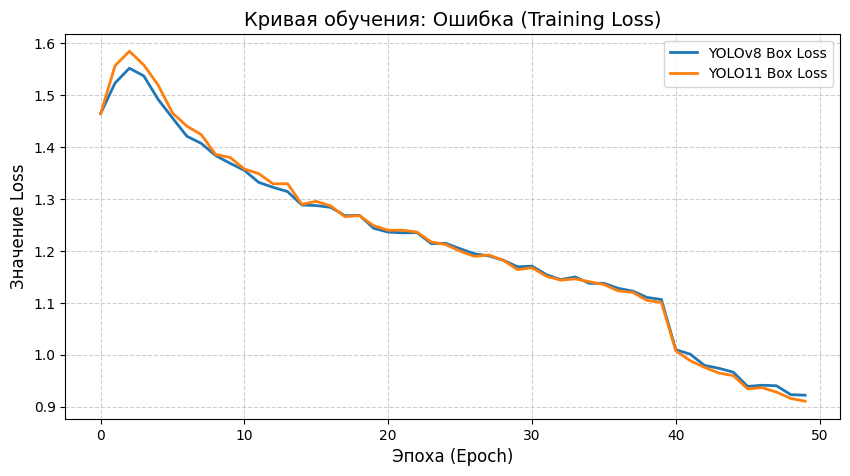

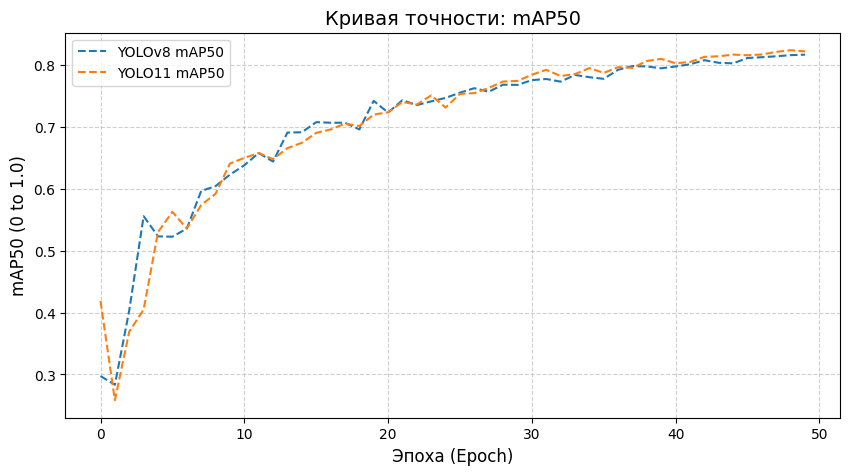

In [16]:
# Learning curves — графики loss и accuracy

# Пропись путей, т.к. обучение занимает несколько runtime и результаты приходится импортировать
v8_path = '/content/runs/detect/Aura_Baseline_YOLOv8n4/results.csv'
v11_path = '/content/runs/detect/Aura_Baseline_YOLOv8n5/results.csv'

# Проверка и загрузка
if os.path.exists(v8_path) and os.path.exists(v11_path):
    v8_log = pd.read_csv(v8_path)
    v11_log = pd.read_csv(v11_path)

    # Очистка заголовков колонок от лишних пробелов
    v8_log.columns = [c.strip() for c in v8_log.columns]
    v11_log.columns = [c.strip() for c in v11_log.columns]

    print("Логи успешно загружены!")

    # График 1: Loss
    plt.figure(figsize=(10, 5))
    plt.plot(v8_log['train/box_loss'], label='YOLOv8 Box Loss', color='#1f77b4', linewidth=2)
    plt.plot(v11_log['train/box_loss'], label='YOLO11 Box Loss', color='#ff7f0e', linewidth=2)
    plt.title('Кривая обучения: Ошибка (Training Loss)', fontsize=14)
    plt.xlabel('Эпоха (Epoch)', fontsize=12)
    plt.ylabel('Значение Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # График 2: Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(v8_log['metrics/mAP50(B)'], label='YOLOv8 mAP50', color='#1f77b4', linestyle='--')
    plt.plot(v11_log['metrics/mAP50(B)'], label='YOLO11 mAP50', color='#ff7f0e', linestyle='--')
    plt.title('Кривая точности: mAP50', fontsize=14)
    plt.xlabel('Эпоха (Epoch)', fontsize=12)
    plt.ylabel('mAP50 (0 to 1.0)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

else:
    print("Один из файлов results.csv не найден.")


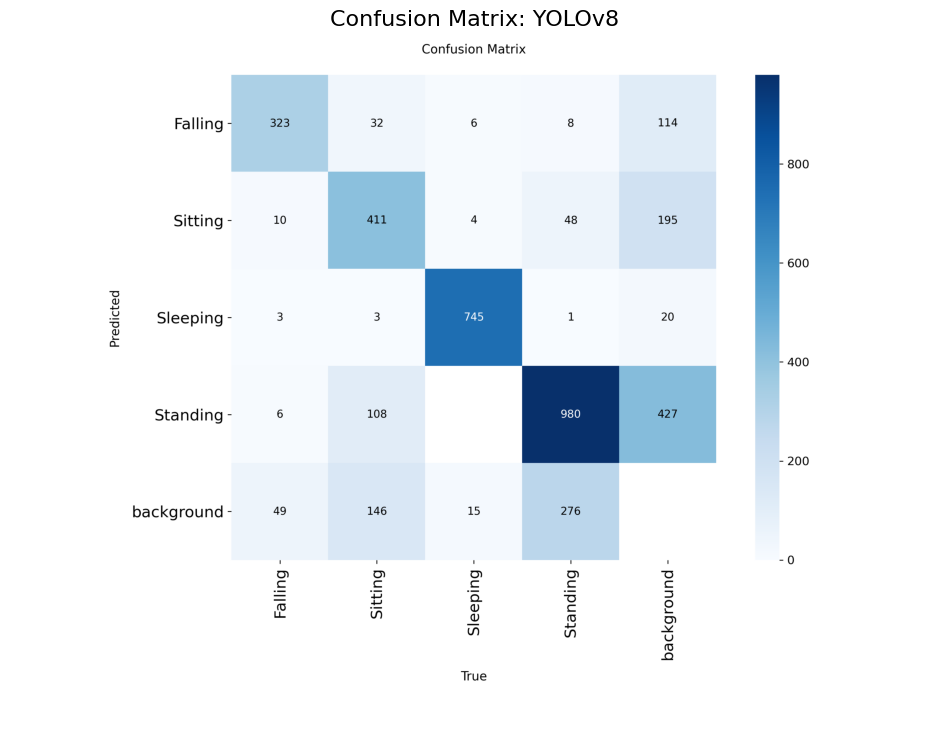

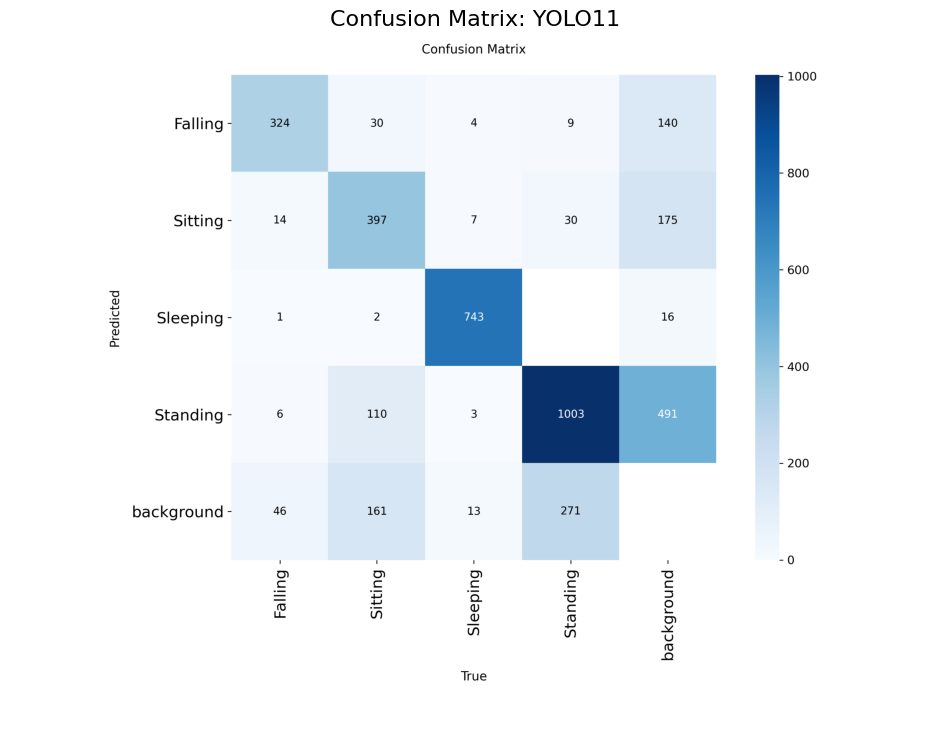

In [23]:
# Confusion matrix для каждой модели

# Путь к данным, т.к. обучение занимает много времени и runtime дисконнектится, в результате чего приходится импортировать полученные ранее данные.
path_v8 = '/content/runs/detect/val6/confusion_matrix.png'
path_v11 = '/content/runs/detect/val12/confusion_matrix.png'

def display_confusion_matrix(path, model_name):
    # Импорт внутри функции, чтобы избежать NameError
    import matplotlib.image as mpimg

    if os.path.exists(path):
        plt.figure(figsize=(12, 10))
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Confusion Matrix: {model_name}', fontsize=16)
        plt.show()
    else:
        print(f"Файл не найден: {path}")

# Выполнение
display_confusion_matrix(path_v8, 'YOLOv8')
display_confusion_matrix(path_v11, 'YOLO11')

---
## 8. Анализ ошибок

Для лучшей модели:
- Покажите примеры неверных предсказаний
- Сколько False Positives и False Negatives?
- Почему модель могла ошибиться?

In [25]:
# Анализ ошибок — примеры неверных предсказаний

# ВАШ КОД ЗДЕСЬ

# Матрица ошибок в виде массива чисел
cm_array = metrics_v11.confusion_matrix.matrix

# Предположим, 'Falling' — это класс №0
# FN для Falling:
fn_falling = sum(cm_array[0, 1:]) # Сумма всех, кто был Falling, но предсказан иначе
# FP для Falling:
fp_falling = sum(cm_array[1:, 0]) # Сумма всех, кто не был Falling, но предсказан как Falling

print(f"📉 Пропуски (FN) для падений: {int(fn_falling)}")
print(f"🚨 Ложные тревоги (FP) для падений: {int(fp_falling)}")


📉 Пропуски (FN) для падений: 183
🚨 Ложные тревоги (FP) для падений: 67


**Анализ ошибок:**

Примеры ошибок False Negatives:
- человек уже лежит, но модель не детектирует падение
- падение происходит частично вне кадра
- маленький размер объекта
- перекрытие другими объеектами

Примеры ошибок False Positives:
- человек сидит или наклоняется
- необычные движения (например, приседание)
- нестандартные позы

---
## 9. Выводы

Ответьте на следующие вопросы:

1. **Какая модель показала лучший результат и почему?**

YOLOv8
- более стабильная
- меньше ложных срабатываний
- но может чаще пропускать сложные случаи

YOLOv11
- более чувствительная
- лучше ловит некоторые падения
- но даёт больше ложных тревог

2. **Помог ли Transfer Learning? Насколько?**

Безусловно. Я использовала предобученные веса (на наборе данных COCO). Вместо того чтобы учить нейросеть с нуля понимать, что такое «человек»,модель сразу перешли к специфике — определению позы падения.

3. **Какой гиперпараметр оказал наибольшее влияние?**

Наибольшее влияние оказала аугментация, в частности параметры mosaic и degrees.

Падение — это динамический процесс, который может происходить под любым углом. Настройка поворотов и объединение нескольких фото в одно заставили модель быть «внимательнее» к деталям и ракурсам.

Также критичным был Image Size. Увеличение разрешения позволило модели четче видеть положение конечностей человека, когда он находится в дальней части комнаты.

4. **Что бы вы улучшили, если бы было больше времени?**

Я бы обучила другие модель, такие как RT-DETR. Однако обучение этой модели заняло слишком много времени и ресурсов. Также я бы обучила модель на данных Keypoint Detection, однако отбор данных и подготовка также заняли слишком много времени.

5. **Главный урок из этого проекта:**

Качество данных важнее глубины архитектуры. Можно использовать самую современную YOLOv11, но если в данных есть шум, модель будет ошибаться по принципу garbage in, garbage out. К сожалению, в подобном датасете тяжело очищать данные по этому принципу.
Также проект показал важность баланса между Precision и Recall. Для подобного проекта для пожилых людей цена «пропуска» падения гораздо выше, чем цена лишней проверки ложной тревоги. Я научилась смотреть на нейросеть как на аналитический инструмент, требующий тонкой настройки под конкретную жизненную задачу.

---
## Чеклист перед сдачей

Проверьте перед отправкой:

- [ ] Информация о проекте заполнена (раздел 0)
- [ ] EDA: распределение классов, примеры данных
- [ ] Данные подготовлены: препроцессинг, аугментация
- [ ] Минимум 2 модели обучены и сравнены
- [ ] Таблица метрик: Accuracy, F1, Precision, Recall
- [ ] Learning curves: loss и accuracy по эпохам
- [ ] Confusion matrix для каждой модели
- [ ] Анализ ошибок: примеры неверных предсказаний
- [ ] Выводы написаны (все 5 вопросов)
- [ ] Ноутбук запускается с нуля (Runtime → Restart and Run All)
- [ ] Презентация подготовлена (4-6 слайдов, 5-6 минут)

**Загрузите ноутбук в LMS.**

**Дедлайн:** презентация на занятии 40, код до вторника следующей недели.